## Training and Testing learner Exam score data set

objectives:
- Create separate train and test sets for both the predictor and response variables.
- Train a model on the training data.
- Assess and compare the model's performance on both the training and testing sets.



## For this project these are libraries i needes to import 



In [21]:
#import libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import train_test_split
import seaborn as sns



In [189]:
#import my data set
df=pd.read_csv('student_exam_scores_large.csv')


In [115]:
#identifing our data set
#hours of studied and attenance_rate are the independant variable 
#while exam_score is the dependant variable

df.head(20)

,Hours_Studied,Attendance_Rate,Exam_Score
0,5.6,88.4,53.7
1,2.9,99.1,45.3
2,6.5,85.9,62.4
3,6.9,91.4,59.9
4,1.1,64.5,27.4
5,2.4,84.5,36.0
6,5.3,76.6,48.7
7,4.4,72.8,47.8
8,5.0,76.2,37.7
9,3.3,81.7,34.5


In [8]:
#lets describe the data set
df.describe()

,Hours_Studied,Attendance_Rate,Exam_Score
count,200.000000,200.000000,200.000000
mean,4.937500,84.864500,49.801000
std,1.750389,9.550984,10.132147
min,1.000000,59.300000,26.200000
25%,3.700000,78.000000,41.975000
50%,4.900000,85.600000,50.100000
75%,6.100000,91.400000,56.800000
max,10.000000,100.000000,75.000000


## Defining The Problem Statement

- using hours studied or attendance rate to predict the linear regression model on exam score
- check on which column will best be predictable with linear regression

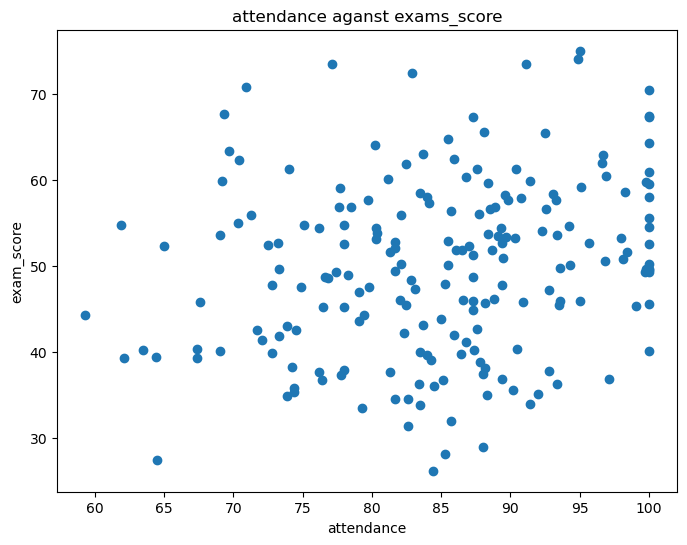

In [30]:
#ploting to see the distribution fof the exam score agaist the attendance \
plt.figure(figsize=(8,6))
plt.scatter(df['Attendance_Rate'],df['Exam_Score'])
plt.title('attendance aganst exams_score')
plt.xlabel('attendance')
plt.ylabel('exam_score')
plt.show()

#from this plot it shows there is no linear relatinship between the attendance rate and Exam_score.

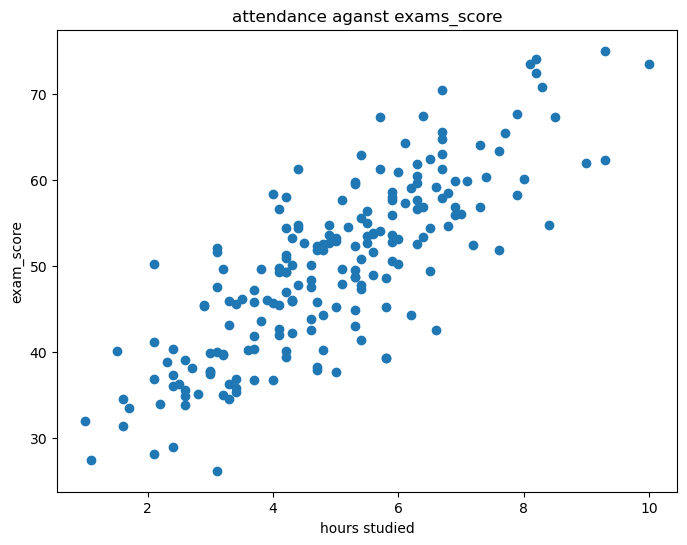

In [32]:
#ploting to see the distribution for the exam score agaist the hours studied
plt.figure(figsize=(8,6))
plt.scatter(df['Hours_Studied'],df['Exam_Score'])
plt.title('attendance aganst exams_score')
plt.xlabel('hours studied')
plt.ylabel('exam_score')
plt.show()

#from the below plot it is visible that the hours studied amd the exam score has a linear relationship

In [38]:
#since there is a relationship let see there corelation to see how theindependent variable affect the dependant variable

df.corr()['Exam_Score']

#the output shows that the hours of studied has a 80% correatio to exam score compared to 20% of attendanc rATE

Hours_Studied      0.814611
Attendance_Rate    0.217725
Exam_Score         1.000000
Name: Exam_Score, dtype: float64

In [39]:
#LET me show the significance of this relationship using pearsonr correlation

pearsonr (df['Hours_Studied'],df['Exam_Score'])


PearsonRResult(statistic=0.8146114441941504, pvalue=1.001854612504006e-48)

##  building a fit linear regression model

In [45]:
#build the model 

Rm = LinearRegression()

In [92]:
# making the Exam_Score and hour of studies a string.
# note: the independant veriable at this point s two dimesional
X= df[['Hours_Studied']]
y= df['Exam_Score']

In [93]:
#now it is time to fit our model
Rm.fit(X,y)

LinearRegression()

In [59]:
#it is time to predict
#y=mx + c

Rm.predict([[5]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([50.09571167])

In [69]:
#let get the values of the other predictive factors which are the intrcept and the  coeficient

coeeficient = Rm.coef_[0]

print (coeeficient)


4.715386649773355


In [72]:
intercept = Rm.intercept_
intercept 

26.518778416744066

In [78]:
avg_hour=df['Hours_Studied'].mean()
avg_hour

4.937499999999999

In [90]:
#predicting the possibility of failure if average is the pass mark

Y = coeeficient*avg_hour + intercept
Y

#ths means to pass the exam a student must nut read below five hours

49.801

In [81]:
#let me see how close my predictions 
y_predict =Rm.predict(X)
y_predict

array([52.92494366, 40.1933997 , 57.16879164, 59.0549463 , 31.70570373,
       37.83570638, 51.51032766, 47.26647968, 50.09571167, 42.07955436,
       58.58340764, 57.64033031, 50.56725033, 60.94110096, 54.33955965,
       42.07955436, 53.39648232, 41.13647703, 58.58340764, 49.624173  ,
       48.20955701, 43.49417036, 61.41263963, 48.68109567, 45.85186368,
       46.79494101, 55.28263698, 53.39648232, 53.86802099, 54.33955965,
       70.37187426, 46.32340235, 45.38032502, 42.55109303, 55.75417565,
       60.94110096, 49.15263434, 42.07955436, 42.55109303, 56.22571431,
       57.16879164, 55.28263698, 43.96570902, 52.45340499, 51.038789  ,
       51.98186633, 58.11186897, 51.98186633, 56.69725298, 50.56725033,
       52.92494366, 56.22571431, 36.42109038, 47.26647968, 45.85186368,
       43.96570902, 47.26647968, 64.24187161, 42.07955436, 59.0549463 ,
       34.06339706, 46.79494101, 51.51032766, 55.75417565, 56.69725298,
       57.64033031, 46.79494101, 45.85186368, 58.11186897, 48.20

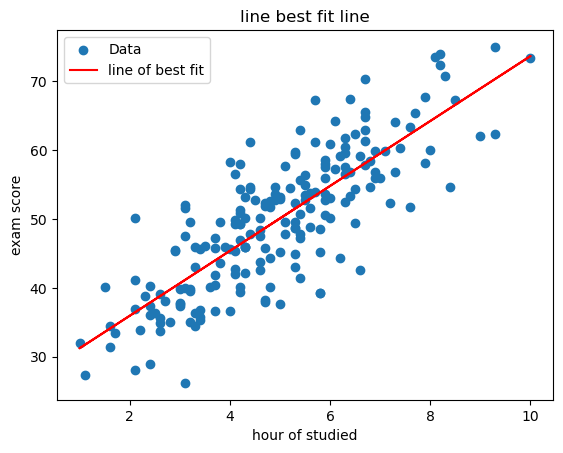

In [188]:
# PLOTING A SCATTER PLOT TO SEE THE LINE OF BEST FIT
plt.scatter( X,y, label='Data')
plt.title('line best fit line')
plt.plot(X,y_predict,label='line of best fit',color='red')
plt.legend()
plt. xlabel('hour of studied')
plt.ylabel('exam score')
plt.show()

## now it is time to train test and split

In [182]:
#training and testing

X_train,X_test,y_train,y_test=train_test_split(X,y ,random_state=42,test_size=0.2)

In [183]:
MODEL = LinearRegression()
MODEL.fit(X_train,y_train)

LinearRegression()

In [184]:
# predict on both the train and test data to see if the prediction work perfectly

y_train_pred = MODEL.predict(X_train)
y_test_pred = MODEL.predict(X_test)

In [185]:
def evaluate_model(y_true,y_pred):
    r2 = r2_score(y_true,y_pred)
    mae =mean_absolute_error(y_true,y_pred)
    mse= mean_squared_error(y_true,y_pred)
    rmse= np.sqrt(mse)
    print('root_2_score:',r2)
    print('mean_absolute_error:',mae)
    print('mean_squared_error:',mse)
    print('root_mean_squared_error:', rmse)

In [186]:
#evaluation of the train data set
evaluate_model(y_train,y_train_pred)

root_2_score: 0.6593179866868724
mean_absolute_error: 4.646334477112401
mean_squared_error: 34.20235219339493
root_mean_squared_error: 5.848277711719488


In [187]:
#evaluation of the test data set

evaluate_model(y_test, y_test_pred)


root_2_score: 0.6752906629968907
mean_absolute_error: 4.704394453850044
mean_squared_error: 35.110396458574755
root_mean_squared_error: 5.92540264105105


## ANALYIZING THE RESIDUALS

In [146]:
#subtracing the _test from the y_test_pred
Residuals= y_test - y_test_pred

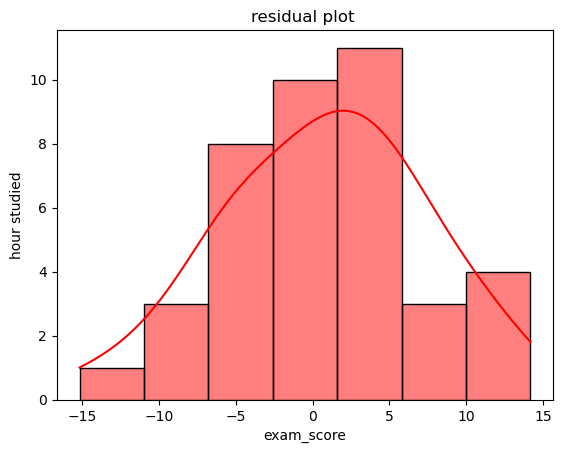

In [150]:
#ploting on the on the residuals
sns.histplot(Residuals,kde=True, color='red')
plt.xlabel('exam_score')
plt.ylabel('hour studied')
plt.title('residual plot ')
plt.show()

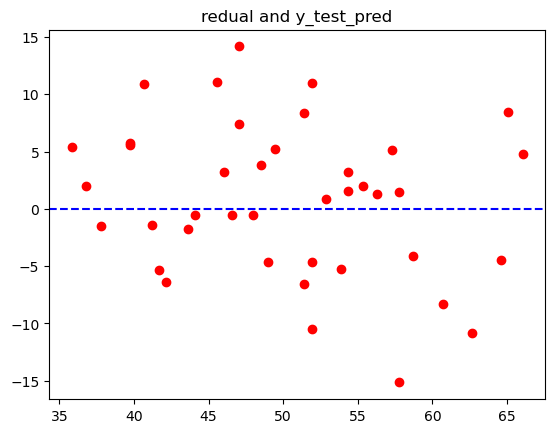

In [181]:
#plot a scatter plot on redual and y_test_pred

plt.scatter(y_test_pred, Residuals,color='r')
plt.axhline(y=0,color='b',linestyle='--')
plt.title('redual and y_test_pred')
plt.show()

## Observation
1. Generalization
   (R2 Score) The R2 score measures the proportion of the variance in the dependent variable that is predictable from the independent variable(s).

Observation: The Test R2
  (0.6753) is slightly higher than the Train R2(0.6593).

Interpretation: This is an excellent result!
It indicates the model performs marginally better on the unseen test data than it did on the data it was trained on.
Crucially, there is no overfitting, which would be indicated by a much lower test score than the train score.

## The model is generalizing well to new data.

2. Error Metrics (MAE, MSE, RMSE)
These metrics quantify the magnitude of the errors the model makes.

Observation: The error metrics (MAE, MSE, RMSE) are all very close between the train set and the test set.

The Test RMSE (5.925) is only slightly higher than the Train RMSE (5.848).

Interpretation: The consistency confirms the R2
  finding: the model's predictive accuracy is reliable. An MAE of 4.704 means, on average, your predictions are about 4.7 units away from the actual yield value.

## conclusion
The model is stable and reliable. The consistent performance across both sets suggests that the current features are well-utilized by the linear model, and the model is not memorizing the training data.The next steps would focus on improving the absolute performance (e.g., trying to raise the $R^2$ score closer to $1.0$) by introducing new features, performing feature engineering, or exploring more complex regression models (like polynomial or decision tree regression).